# Projeto de Mineração de Dados 

**Discente:** Leonardo Espindola Pires

**Professor:** Leandro Nogueira Couto

Universidade Federal de Uberlândia - UFU

Este projeto utilizou o dataset ERENO-2.0-100K, disponível no Kaggle*. 

Parte 1 - Pré-processamento

Parte 2 - Divisão treino/teste

Parte 3 - Treinamento dos modelos lineares e avaliação de desempenho

Parte 4 - Treinamento dos modelos não-lineares e avaliação de desempenho

Parte 5 - Gráficos

*https://www.kaggle.com/datasets/silvioerenoquincozes/ereno-2-0-100k-csv


In [1]:
# Bibliotecas utilizadas
import io
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, RobustScaler

import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 60)


---
## PARTE 1 - Pré-processamento do dataset

#### 1. Remoção das linhas de comentário no formato ARFF/WEKA

Foram removidas todas as linhas de comentários, utilizados em arquivo no formato ARFF/WEKA, como `@` E `%`.

In [2]:
RAW_PATH = ('data/ERENO-2_0-100K.csv')

with open(RAW_PATH, "r", encoding="utf-8") as f:
    raw_lines = f.readlines()

print(f"Total de linhas no arquivo bruto: {len(raw_lines):,}")

header = raw_lines[0]

arff_prefixes = ("@", "%")
data_lines = [header] + [
    line for line in raw_lines[1:] if not line.lstrip().startswith(arff_prefixes)
]

n_removidas = len(raw_lines) - len(data_lines)
print(f"Linhas de comentário/metadado ARFF removidas: {n_removidas}")
print(f"Linhas restantes (cabeçalho + dados): {len(data_lines):,}")


Total de linhas no arquivo bruto: 200,053
Linhas de comentário/metadado ARFF removidas: 54
Linhas restantes (cabeçalho + dados): 199,999


In [3]:
# Carrega o conteúdo já filtrado em um DataFrame
buffer = io.StringIO("".join(data_lines))
df = pd.read_csv(buffer)

del raw_lines, data_lines, buffer  # libera memória

print("Shape do dataset após remoção das linhas ARFF:", df.shape)
df.head(3)


Shape do dataset após remoção das linhas ARFF: (199998, 52)


,Time,isbA,isbB,isbC,vsbA,vsbB,vsbC,isbARmsValue,isbBRmsValue,isbCRmsValue,vsbARmsValue,vsbBRmsValue,vsbCRmsValue,isbATrapAreaSum,isbBTrapAreaSum,isbCTrapAreaSum,vsbATrapAreaSum,vsbBTrapAreaSum,vsbCTrapAreaSum,t,GooseTimestamp,SqNum,StNum,cbStatus,frameLen,ethDst,ethSrc,ethType,gooseTimeAllowedtoLive,gooseAppid,gooseLen,TPID,gocbRef,datSet,goID,test,confRev,ndsCom,numDatSetEntries,APDUSize,protocol,stDiff,sqDiff,gooseLengthDiff,cbStatusDiff,apduSizeDiff,frameLengthDiff,timestampDiff,tDiff,timeFromLastChange,delay,class
0,0.03885,-0.026538,-0.035877,0.060486,-0.039338,0.077393,-0.038062,0.029459,0.025651,0.029991,0.041071,0.042429,0.044336,-40.583960,-38.734222,-39.184131,-39.105512,-39.553336,-39.841038,0.016590,0.038980,1,1,0,200,01:0c:cd:01:2f:81,01:0c:cd:01:2f:80,0x88B8,11000,0x00003001,186,0x8100,LD/LLN0$GO$gcblA,LD/LLN0$IntLockA,IntLockA,FALSE,1,FALSE,25,186,GOOSE,0,0,0,0,0,0,0.005068,0.000000,0.02239,0.000130,grayhole
1,0.03885,-0.026538,-0.035877,0.060486,-0.039338,0.077393,-0.038062,0.029459,0.025651,0.029991,0.041071,0.042429,0.044336,-40.583960,-38.734222,-39.184131,-39.105512,-39.553336,-39.841038,0.016590,0.038980,1,1,0,200,01:0c:cd:01:2f:81,01:0c:cd:01:2f:80,0x88B8,11000,0x00003001,186,0x8100,LD/LLN0$GO$gcblA,LD/LLN0$IntLockA,IntLockA,FALSE,1,FALSE,25,186,GOOSE,0,0,0,0,0,0,0.000000,0.000000,0.02239,0.000130,normal
2,0.37464,0.029923,-0.076646,0.045858,-0.095898,0.055355,0.040523,0.048988,0.053399,0.052915,0.067719,0.067900,0.067984,-39.529398,-39.519038,-39.451131,-39.466810,-39.522075,-39.511112,97.650813,0.374763,87,35,2,200,01:0c:cd:01:2f:81,01:0c:cd:01:2f:80,0x88B8,10599,0x00003001,186,0x8100,LD/LLN0$GO$gcblA,LD/LLN0$IntLockA,IntLockA,FALSE,31,FALSE,25,186,GOOSE,34,86,0,1,0,0,0.335783,97.634223,-97.27605,0.000123,injection


#### 2. Verificação inicial do dataset

In [4]:
print("Tipos de dados:")
print(df.dtypes)


Tipos de dados:
Time                      float64
isbA                      float64
isbB                      float64
isbC                      float64
vsbA                      float64
vsbB                      float64
vsbC                      float64
isbARmsValue              float64
isbBRmsValue              float64
isbCRmsValue              float64
vsbARmsValue              float64
vsbBRmsValue              float64
vsbCRmsValue              float64
isbATrapAreaSum           float64
isbBTrapAreaSum           float64
isbCTrapAreaSum           float64
vsbATrapAreaSum           float64
vsbBTrapAreaSum           float64
vsbCTrapAreaSum           float64
t                         float64
GooseTimestamp            float64
SqNum                       int64
StNum                       int64
cbStatus                    int64
frameLen                    int64
ethDst                        str
ethSrc                        str
ethType                       str
gooseTimeAllowedtoLive      int6

In [5]:
print("Distribuição da variável alvo (class):")
print(df["class"].value_counts())
print()
print(f"Número de classes: {df['class'].nunique()}")


Distribuição da variável alvo (class):
class
normal                    39999
injection                 20000
high_StNum                20000
random_replay             20000
masquerade_fake_normal    20000
inverse_replay            20000
masquerade_fake_fault     20000
poisoned_high_rate        20000
grayhole                  19999
Name: count, dtype: int64

Número de classes: 9


#### 3. Remoção das colunas constantes

Uma das tarefas realizadas no pré-processamento foi a redução de dimensionalidade. Foram removidas as colunas categóricas e numéricas com dados constantes (variância zero). 

In [6]:
# Colunas categóricas constantes (exceto a variável alvo)
cat_cols = df.select_dtypes(include=["object", "str"]).columns.tolist()
cat_cols_excl_target = [c for c in cat_cols if c != "class"]
constant_cat_cols = [c for c in cat_cols_excl_target if df[c].nunique() == 1]

print(f"Colunas categóricas constantes ({len(constant_cat_cols)}):")
print(constant_cat_cols)

df.drop(columns=constant_cat_cols, inplace=True)


Colunas categóricas constantes (11):
['ethDst', 'ethSrc', 'ethType', 'gooseAppid', 'TPID', 'gocbRef', 'datSet', 'goID', 'test', 'ndsCom', 'protocol']


In [7]:
# Colunas numéricas constantes
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
constant_num_cols = [c for c in num_cols if df[c].nunique() == 1]

print(f"Colunas numéricas constantes ({len(constant_num_cols)}):")
print(constant_num_cols)

df.drop(columns=constant_num_cols, inplace=True)

print(f"\nShape após remoção de colunas constantes: {df.shape}")


Colunas numéricas constantes (7):
['frameLen', 'gooseLen', 'numDatSetEntries', 'APDUSize', 'gooseLengthDiff', 'apduSizeDiff', 'frameLengthDiff']

Shape após remoção de colunas constantes: (199998, 34)


#### 4. Busca por valores nulos

Foi verificado que a versão do dataset utilizado não possui valores nulos. No entanto, o código foi mantido pensando em sua replicabilidade.

In [8]:
null_counts = df.isnull().sum()
null_counts = null_counts[null_counts > 0]

if null_counts.empty:
    print("Nenhum valor nulo encontrado no dataset.")
else:
    print("Colunas com valores nulos:")
    print(null_counts)

    # Remove linhas sem rótulo
    if df["class"].isnull().any():
        n_antes = len(df)
        df.dropna(subset=["class"], inplace=True)
        print(f"\nLinhas removidas por 'class' nula: {n_antes - len(df)}")

    # Utilizada a mediana para numéricas e moda para categóricas
    num_cols_now = df.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols_now = [c for c in df.select_dtypes(include=["object", "str"]).columns if c != "class"]

    for col in num_cols_now:
        if df[col].isnull().any():
            df[col] = df[col].fillna(df[col].median())

    for col in cat_cols_now:
        if df[col].isnull().any():
            df[col] = df[col].fillna(df[col].mode()[0])

print(f"\nTotal de valores nulos após tratamento: {df.isnull().sum().sum()}")


Nenhum valor nulo encontrado no dataset.

Total de valores nulos após tratamento: 0


#### 5. Codificação de variáveis categóricas (One-Hot Encoding)

No passo 2. foram removidas 11 variáveis categóricas constantes (`ethDst`, `ethSrc`, `ethType`, `gooseAppid`, `TPID`, `gocbRef`, `datSet`, `goID`, `test`, `ndsCom`, `protocol`). Dessa forma, não restou nenhuma outra categórica para ser codificada. **Justificativa:** como o dataset utilizado é um recorte (200k linhas) de um dataset maior, nesse subconjunto não houve variação nas referidas colunas.


In [9]:
# Identifica colunas categóricas (excluindo a variável alvo 'class')
cat_features = [
    c for c in df.select_dtypes(include=["object", "str"]).columns if c != "class"
]

print(f"Colunas categóricas encontradas: {len(cat_features)}")
print(cat_features)


Colunas categóricas encontradas: 0
[]


In [10]:
# Mantido o tratamento das colunas categóricas, para testes futuros com o dataset completo (sem remoção de colunas)
import re
from sklearn.preprocessing import OneHotEncoder

if cat_features:
    for col in cat_features:
        df[col] = df[col].astype(str).str.strip()

    ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
    ohe_array = ohe.fit_transform(df[cat_features])
    
    # 1. Limpeza dos nomes usando Regex (Substitui caracteres incompatíveis por '_')
    ohe_col_names = [
        re.sub(r'_+', '_', re.sub(r'[^A-Za-z0-9_]', '_', c)).strip('_')
        for c in ohe.get_feature_names_out(cat_features)
    ]

    # 2. Tratamento de Nomes Duplicados
    seen = {}
    final_col_names = []
    for name in ohe_col_names:
        if name in seen:
            seen[name] += 1
            final_col_names.append(f"{name}_{seen[name]}")
        else:
            seen[name] = 0
            final_col_names.append(name)

    # 3. Criação do DataFrame codificado
    df_ohe = pd.DataFrame(ohe_array, columns=final_col_names, index=df.index)

    # 4. Substitui as colunas categóricas originais pelas novas colunas binárias
    df = pd.concat([df.drop(columns=cat_features), df_ohe], axis=1)
    
    print(f"One-Hot Encoding aplicado com sucesso.")
    print(f"Novas colunas binárias criadas: {len(final_col_names)}")
    print(f"Shape do dataset após One-Hot Encoding: {df.shape}")
else:
    print("Nenhuma coluna categórica restante para codificar.")

Nenhuma coluna categórica restante para codificar.


#### 6. Codificação da variável alvo 

Foi utilizado o LabelEncoder do Scikit-Learn para codificar a variável alvo (class), visto que ela possui 9 rótulos.

In [11]:
le = LabelEncoder()
df["class_encoded"] = le.fit_transform(df["class"].str.strip())

class_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Mapeamento classe -> código:")
for k, v in class_mapping.items():
    print(f"  {k:30s} -> {v}")


Mapeamento classe -> código:
  grayhole                       -> 0
  high_StNum                     -> 1
  injection                      -> 2
  inverse_replay                 -> 3
  masquerade_fake_fault          -> 4
  masquerade_fake_normal         -> 5
  normal                         -> 6
  poisoned_high_rate             -> 7
  random_replay                  -> 8


#### 7. Padronização de escala

Foi utilizado o RobustScaler, que utiliza a mediana e o IQR (intervalo interquartil), no intuito de minimizar a ação de outliers.

In [12]:
# Separação features (X) / target (y)
X = df.drop(columns=["class", "class_encoded"])
y = df["class_encoded"]

num_features = X.select_dtypes(include=[np.number]).columns.tolist()
print(f"Número de features numéricas a serem padronizadas: {len(num_features)}")
print(num_features)


Número de features numéricas a serem padronizadas: 33
['Time', 'isbA', 'isbB', 'isbC', 'vsbA', 'vsbB', 'vsbC', 'isbARmsValue', 'isbBRmsValue', 'isbCRmsValue', 'vsbARmsValue', 'vsbBRmsValue', 'vsbCRmsValue', 'isbATrapAreaSum', 'isbBTrapAreaSum', 'isbCTrapAreaSum', 'vsbATrapAreaSum', 'vsbBTrapAreaSum', 'vsbCTrapAreaSum', 't', 'GooseTimestamp', 'SqNum', 'StNum', 'cbStatus', 'gooseTimeAllowedtoLive', 'confRev', 'stDiff', 'sqDiff', 'cbStatusDiff', 'timestampDiff', 'tDiff', 'timeFromLastChange', 'delay']


In [13]:
robust = RobustScaler()

X_scaled = X.copy()
X_scaled[num_features] = robust.fit_transform(X[num_features])

print("Estatísticas ANTES do RobustScaler (coluna 'vsbCTrapAreaSum'):")
print(X["vsbCTrapAreaSum"].describe())
print()
print("Estatísticas DEPOIS do RobustScaler (coluna 'vsbCTrapAreaSum'):")
print(X_scaled["vsbCTrapAreaSum"].describe())


Estatísticas ANTES do RobustScaler (coluna 'vsbCTrapAreaSum'):
count    199998.000000
mean        -39.493870
std           0.099677
min         -39.940222
25%         -39.526453
50%         -39.500844
75%         -39.472397
max         -39.097114
Name: vsbCTrapAreaSum, dtype: float64

Estatísticas DEPOIS do RobustScaler (coluna 'vsbCTrapAreaSum'):
count    199998.000000
mean          0.129011
std           1.843971
min          -8.128273
25%          -0.473748
50%           0.000000
75%           0.526252
max           7.468827
Name: vsbCTrapAreaSum, dtype: float64


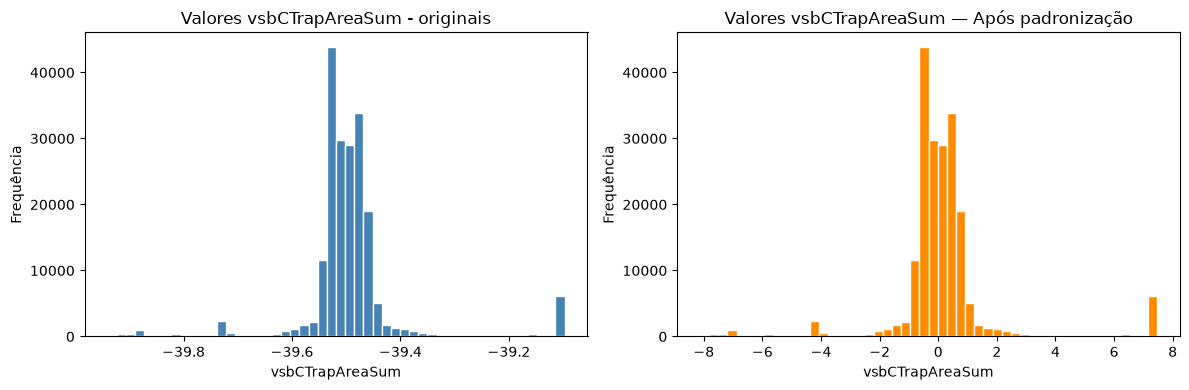

In [14]:
# Comparação visual: antes x depois do RobustScaler
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(X["vsbCTrapAreaSum"], bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("Valores vsbCTrapAreaSum - originais")
axes[0].set_xlabel("vsbCTrapAreaSum")
axes[0].set_ylabel("Frequência")

axes[1].hist(X_scaled["vsbCTrapAreaSum"], bins=50, color="darkorange", edgecolor="white")
axes[1].set_title("Valores vsbCTrapAreaSum — Após padronização")
axes[1].set_xlabel("vsbCTrapAreaSum")
axes[1].set_ylabel("Frequência")

plt.tight_layout()
plt.show()


#### 8. Dataset final pré-processado

In [15]:
df_final = X_scaled.copy()
df_final["class"] = df["class"].values
df_final["class_encoded"] = y.values

print("Shape final:", df_final.shape)
df_final.head()


Shape final: (199998, 35)


,Time,isbA,isbB,isbC,vsbA,vsbB,vsbC,isbARmsValue,isbBRmsValue,isbCRmsValue,vsbARmsValue,vsbBRmsValue,vsbCRmsValue,isbATrapAreaSum,isbBTrapAreaSum,isbCTrapAreaSum,vsbATrapAreaSum,vsbBTrapAreaSum,vsbCTrapAreaSum,t,GooseTimestamp,SqNum,StNum,cbStatus,gooseTimeAllowedtoLive,confRev,stDiff,sqDiff,cbStatusDiff,timestampDiff,tDiff,timeFromLastChange,delay,class,class_encoded
0,-1.092498,-0.246465,-0.253853,0.515405,-0.291663,0.563572,-0.328811,-1.244693,-1.255310,-1.959890,-6.378712,-40.498822,-69.625993,-2.169180,3.321182,0.623421,7.016860,-0.939375,-6.293428,-0.986063,-1.092498,-0.296296,-0.531768,0.0,0.0,0.0,0.000000,0.000000,0.0,-0.255355,0.000000,-0.133154,-0.159667,grayhole,0
1,-1.092498,-0.246465,-0.253853,0.515405,-0.291663,0.563572,-0.328811,-1.244693,-1.255310,-1.959890,-6.378712,-40.498822,-69.625993,-2.169180,3.321182,0.623421,7.016860,-0.939375,-6.293428,-0.986063,-1.092498,-0.296296,-0.531768,0.0,0.0,0.0,0.000000,0.000000,0.0,-0.286927,0.000000,-0.133154,-0.159667,normal,6
2,-1.092410,0.172123,-0.568512,0.399997,-0.766964,0.403191,0.317334,-0.934765,-0.744056,-0.867863,-0.035640,-0.072860,0.382482,-0.576225,0.441884,0.189186,0.678007,-0.392265,-0.189940,-0.958925,-1.092410,2.888889,-0.484807,2.0,-401.0,30.0,0.246377,6.615385,1.0,1.804856,3.944398,-1.693714,-0.193913,injection,2
3,-1.092376,3.155608,-0.850416,-1.052963,0.164136,0.600722,-0.672352,0.734012,-0.662930,-0.432402,-0.733163,1.025962,-4.864565,7.251303,-3.820833,-1.748528,-5.477670,1.147907,2.355490,0.792928,-1.092376,0.407407,115.915746,0.0,0.0,0.0,610.681159,-5.153846,1.0,0.514584,254.619998,-102.777091,-0.511212,high_StNum,1
4,-1.092309,0.736280,-1.150214,0.164159,-0.551617,-0.164567,0.742650,0.038665,0.269468,0.035944,0.070509,0.502564,-0.278131,0.386888,-0.121535,-0.613979,0.495297,0.237405,-0.653949,0.937207,-1.092309,1.962963,36.602210,0.0,0.0,0.0,-416.108696,3.230769,0.0,1.313488,20.969977,-111.098158,-0.155647,high_StNum,1


In [16]:
# Exporta o resultado para um novo arquivo CSV
df_final.to_csv('data/ERENO-2_0-100K_preprocessado.csv', index=False)
print("Dataset salvo em: ERENO-2_0-100K_preprocessado.csv")


Dataset salvo em: ERENO-2_0-100K_preprocessado.csv


---
## PARTE 2 — Divisão treino/teste

Foi utilizado 50/50% para o split do dataset (sem embaralhamento dos dados), conforme justificado no artigo.

#### 1. Distribuição das classes

In [17]:
# 3) Distribuição de classes em cada metade do arquivo
classes_seq = df["class"].str.strip().tolist()
n = len(classes_seq)
metade = n // 2

seg1 = df.iloc[:metade]
seg2 = df.iloc[metade:]

print(f"Tamanho da 1ª metade: {len(seg1)} | Tamanho da 2ª metade: {len(seg2)}")
print()
print("Distribuição de classes — 1ª metade:")
print(seg1["class"].str.strip().value_counts())
print()
print("Distribuição de classes — 2ª metade:")
print(seg2["class"].str.strip().value_counts())


Tamanho da 1ª metade: 99999 | Tamanho da 2ª metade: 99999

Distribuição de classes — 1ª metade:
class
normal                    19999
grayhole                  10000
injection                 10000
high_StNum                10000
random_replay             10000
masquerade_fake_normal    10000
inverse_replay            10000
masquerade_fake_fault     10000
poisoned_high_rate        10000
Name: count, dtype: int64

Distribuição de classes — 2ª metade:
class
normal                    20000
random_replay             10000
high_StNum                10000
injection                 10000
masquerade_fake_normal    10000
inverse_replay            10000
poisoned_high_rate        10000
masquerade_fake_fault     10000
grayhole                   9999
Name: count, dtype: int64


#### 2. Divisão dos dados de treinamento e teste (50/50)

In [18]:
train_size = metade  # ≈ 99.999 linhas (1ª metade = treino, 2ª metade = teste)

X_train_raw = X.iloc[:train_size]
X_test_raw = X.iloc[train_size:]
y_train = y.iloc[:train_size]
y_test = y.iloc[train_size:]

print(f"Treino: {X_train_raw.shape[0]} linhas | Teste: {X_test_raw.shape[0]} linhas")
print()
print("Distribuição de classes no treino:")
print(y_train.value_counts().sort_index())
print()
print("Distribuição de classes no teste:")
print(y_test.value_counts().sort_index())


Treino: 99999 linhas | Teste: 99999 linhas

Distribuição de classes no treino:
class_encoded
0    10000
1    10000
2    10000
3    10000
4    10000
5    10000
6    19999
7    10000
8    10000
Name: count, dtype: int64

Distribuição de classes no teste:
class_encoded
0     9999
1    10000
2    10000
3    10000
4    10000
5    10000
6    20000
7    10000
8    10000
Name: count, dtype: int64


In [19]:
# Para evitar data leakage, o RobustScaler foi ajustado (fit) apenas nos dados de treino e depois 
# aplicado (transform) nos dados de teste.

scaler_final = RobustScaler()

X_train = X_train_raw.copy()
X_test = X_test_raw.copy()

X_train[num_features] = scaler_final.fit_transform(X_train_raw[num_features])
X_test[num_features] = scaler_final.transform(X_test_raw[num_features])

print("Padronização concluída (apenas com dados de treino).")


Padronização concluída (apenas com dados de treino).


---
## PARTE 3 — Treinamento dos modelos lineares e avaliação de desempenho

Foram treinados 2 classificadores lineares (Logistic Regression e Linear SVM) em 4 cenários diferentes, sendo dois cenários de Base (baseline) e dois com hiperparâmetros otimizados (Hyperparameter Tuning), organizados da seguinte maneira:

1. Logistic Regression - Baseline (max_iter=2000 e random_state=42)
2. Linear SVM - Baseline (random_state=42)
3. Logistic Regression - Otimizado (utilizado RandomizedSearchCV)
4. Linear SVM - Otimizado (utilizado RandomizedSearchCV)

#### 1. Treinamento do classificador Logistic Regression - Baseline

In [20]:
import time
from sklearn.linear_model import LogisticRegression

start_time = time.time()

clf = LogisticRegression(max_iter=2000, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

elapsed_logreg_base = time.time() - start_time

print("Modelo treinado com sucesso.")
print(f"Número de classes: {len(clf.classes_)}")
print(f"Tempo de execução (treino + predição): {elapsed_logreg_base:.2f} segundos")


Modelo treinado com sucesso.
Número de classes: 9
Tempo de execução (treino + predição): 109.50 segundos


g:\Meu Drive\Doutorado\Disciplinas\Mineracao\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


#### 2. Treinamento do SVM Linear - Baseline

In [21]:
from sklearn.svm import LinearSVC

start_time = time.time()

svm_clf_base = LinearSVC(random_state=42)
svm_clf_base.fit(X_train, y_train)

y_pred_svm_base = svm_clf_base.predict(X_test)

elapsed_svm_base = time.time() - start_time

print("Modelo treinado com sucesso.")
print(f"Tempo de execução (treino + predição): {elapsed_svm_base:.2f} segundos")


Modelo treinado com sucesso.
Tempo de execução (treino + predição): 63.51 segundos


#### 3. Avaliação do desempenho dos modelos baseline
Logistic Regression x Linear SVM

In [22]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

# --- Logistic Regression (baseline) ---
acc = accuracy_score(y_test, y_pred)
prec_macro = precision_score(y_test, y_pred, average="macro")
rec_macro = recall_score(y_test, y_pred, average="macro")
f1_macro = f1_score(y_test, y_pred, average="macro")

# --- Linear SVM (baseline) ---
acc_svm_base = accuracy_score(y_test, y_pred_svm_base)
prec_macro_svm_base = precision_score(y_test, y_pred_svm_base, average="macro")
rec_macro_svm_base = recall_score(y_test, y_pred_svm_base, average="macro")
f1_macro_svm_base = f1_score(y_test, y_pred_svm_base, average="macro")

print("=" * 50)
print("DESEMPENHO — Logistic Regression (baseline)")
print("=" * 50)
print(f"Tempo de execução:  {elapsed_logreg_base:.2f}s")
print(f"Acurácia:           {acc:.4f}")
print(f"Precisão (macro):   {prec_macro:.4f}")
print(f"Recall (macro):     {rec_macro:.4f}")
print(f"F1-Score (macro):   {f1_macro:.4f}")
print()
print("Relatório de classificação por classe:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

print("=" * 50)
print("DESEMPENHO — Linear SVM (baseline)")
print("=" * 50)
print(f"Tempo de execução:  {elapsed_svm_base:.2f}s")
print(f"Acurácia:           {acc_svm_base:.4f}")
print(f"Precisão (macro):   {prec_macro_svm_base:.4f}")
print(f"Recall (macro):     {rec_macro_svm_base:.4f}")
print(f"F1-Score (macro):   {f1_macro_svm_base:.4f}")
print()
print("Relatório de classificação por classe:")
print(classification_report(y_test, y_pred_svm_base, target_names=le.classes_))

print("=" * 50)
print("COMPARAÇÃO DIRETA — BASELINES")
print("=" * 50)
print(f"{'Métrica':<20s} {'LogReg (baseline)':>16s} {'Linear SVM (baseline)':>20s}")
print(f"{'Acurácia':<20s} {acc:>16.4f} {acc_svm_base:>20.4f}")
print(f"{'Precisão (macro)':<20s} {prec_macro:>16.4f} {prec_macro_svm_base:>20.4f}")
print(f"{'Recall (macro)':<20s} {rec_macro:>16.4f} {rec_macro_svm_base:>20.4f}")
print(f"{'F1-Score (macro)':<20s} {f1_macro:>16.4f} {f1_macro_svm_base:>20.4f}")
print(f"{'Tempo (s)':<20s} {elapsed_logreg_base:>16.2f} {elapsed_svm_base:>20.2f}")


DESEMPENHO — Logistic Regression (baseline)
Tempo de execução:  109.50s
Acurácia:           0.7827
Precisão (macro):   0.8057
Recall (macro):     0.7769
F1-Score (macro):   0.7814

Relatório de classificação por classe:
                        precision    recall  f1-score   support

              grayhole       0.65      0.42      0.51      9999
            high_StNum       1.00      0.99      1.00     10000
             injection       1.00      0.98      0.99     10000
        inverse_replay       0.87      0.71      0.78     10000
 masquerade_fake_fault       0.93      0.97      0.95     10000
masquerade_fake_normal       0.84      0.87      0.85     10000
                normal       0.59      0.83      0.69     20000
    poisoned_high_rate       0.82      0.91      0.86     10000
         random_replay       0.54      0.31      0.39     10000

              accuracy                           0.78     99999
             macro avg       0.81      0.78      0.78     99999
          

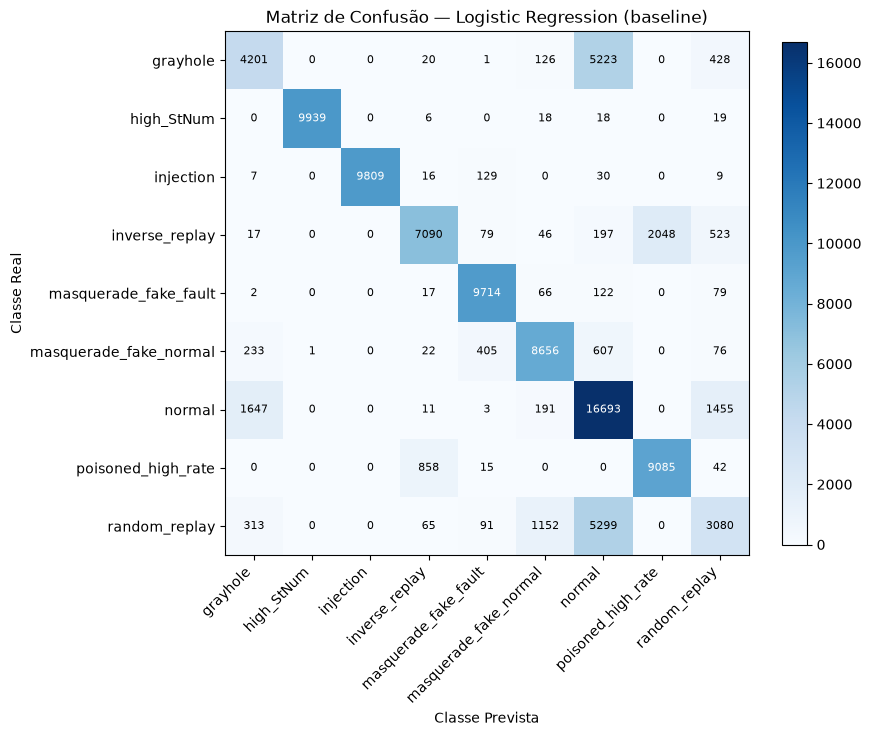

In [23]:
# Matriz de confusão
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(le.classes_)))
ax.set_yticks(range(len(le.classes_)))
ax.set_xticklabels(le.classes_, rotation=45, ha="right")
ax.set_yticklabels(le.classes_)
ax.set_xlabel("Classe Prevista")
ax.set_ylabel("Classe Real")
ax.set_title("Matriz de Confusão — Logistic Regression (baseline)")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=8)

plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()


#### 4. Preparação dos dados de treinamento para otimização de hiperparâmetros.

Foi utilizado o `TimeSeriesSplit` com 3 Folds (`n_splits=3`). Essa estratégia foi utilizada para evitar o temporal data leakage, que ocorreria caso fosse utilizado o K-Fold cross validation. 

Devido à divisão cronológica original do dataset, o `TimeSeriesSplit` gera 3 pares (treino/validação internos), que funcionam como uma janela deslizante e crescem em tamanho a cada fold.

In [24]:
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report
import time

tscv = TimeSeriesSplit(n_splits=3)

print(f"Número de folds: {tscv.get_n_splits()}")
print(f"Tamanho do conjunto de treino (X_train): {X_train.shape[0]} linhas")

# Tamanho de cada fold gerado pelo TimeSeriesSplit
for i, (train_idx, val_idx) in enumerate(tscv.split(X_train), start=1):
    print(
        f"Fold {i}: treino-interno = {len(train_idx):>6} linhas "
        f"(índices 0–{train_idx[-1]}) | "
        f"validação-interna = {len(val_idx):>6} linhas "
        f"(índices {val_idx[0]}–{val_idx[-1]})"
    )


Número de folds: 3
Tamanho do conjunto de treino (X_train): 99999 linhas
Fold 1: treino-interno =  25002 linhas (índices 0–25001) | validação-interna =  24999 linhas (índices 25002–50000)
Fold 2: treino-interno =  50001 linhas (índices 0–50000) | validação-interna =  24999 linhas (índices 50001–74999)
Fold 3: treino-interno =  75000 linhas (índices 0–74999) | validação-interna =  24999 linhas (índices 75000–99998)


#### 5. Treinamento e otimização do Logistic Regression - Melhores hiperparâmetros

In [25]:
# Modelo base: Regressão Logística com pesos balanceados por classe
logreg_base = LogisticRegression(
    class_weight="balanced",  # compensa o desbalanceamento sem remover dados
    random_state=42,
)

# Espaço de busca de hiperparâmetros
param_dist_logreg = {
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ["l1", "l2"],
    "solver": ["saga"],       # único solver compatível com l1 e l2 em larga escala
    "max_iter": [1000],
}

random_search_logreg = RandomizedSearchCV(
    estimator=logreg_base,
    param_distributions=param_dist_logreg,
    n_iter=5,                 # 5 combinações aleatórias (não Grid Search completo)
    scoring="f1_macro",       # peso igual a todas as classes (cenário desbalanceado)
    cv=tscv,                  # validação cronológica (TimeSeriesSplit)
    n_jobs=-1,                # paraleliza usando todos os núcleos disponíveis
    random_state=42,          # reprodutibilidade da amostragem aleatória
    verbose=1,
)

print("Iniciando busca de hiperparâmetros — Regressão Logística...")
start_time = time.time()

random_search_logreg.fit(X_train, y_train)

elapsed_logreg = time.time() - start_time
print(f"\nBusca concluída em {elapsed_logreg:.2f} segundos ({elapsed_logreg/60:.2f} minutos).")
print(f"\nMelhores hiperparâmetros (Regressão Logística):")
print(random_search_logreg.best_params_)
print(f"\nMelhor score f1_macro (validação interna, TimeSeriesSplit): "
      f"{random_search_logreg.best_score_:.4f}")


Iniciando busca de hiperparâmetros — Regressão Logística...
Fitting 3 folds for each of 5 candidates, totalling 15 fits


g:\Meu Drive\Doutorado\Disciplinas\Mineracao\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
g:\Meu Drive\Doutorado\Disciplinas\Mineracao\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(



Busca concluída em 1048.73 segundos (17.48 minutos).

Melhores hiperparâmetros (Regressão Logística):
{'solver': 'saga', 'penalty': 'l1', 'max_iter': 1000, 'C': 0.01}

Melhor score f1_macro (validação interna, TimeSeriesSplit): 0.6247


g:\Meu Drive\Doutorado\Disciplinas\Mineracao\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


#### 6. Treinamento e otimização do Linear SVM - Melhores hiperparâmetros

In [26]:
# Modelo base: Linear SVM com pesos balanceados por classe
svm_base = LinearSVC(
    class_weight="balanced",  # compensa o desbalanceamento sem remover dados
    random_state=42,
)

# Espaço de busca de hiperparâmetros
param_dist_svm = {
    "C": [0.01, 0.1, 1, 10, 100],
    "loss": ["hinge", "squared_hinge"],
    "max_iter": [2000],       # iterações ampliadas para garantir convergência
}

random_search_svm = RandomizedSearchCV(
    estimator=svm_base,
    param_distributions=param_dist_svm,
    n_iter=5,                 # 5 combinações aleatórias (não Grid Search completo)
    scoring="f1_macro",       # peso igual a todas as classes (cenário desbalanceado)
    cv=tscv,                  # validação cronológica (TimeSeriesSplit)
    n_jobs=-1,                # paraleliza usando todos os núcleos disponíveis
    random_state=42,          # reprodutibilidade da amostragem aleatória
    verbose=1,
)

print("Iniciando busca de hiperparâmetros — SVM (LinearSVC)...")
start_time = time.time()

random_search_svm.fit(X_train, y_train)

elapsed_svm = time.time() - start_time
print(f"\nBusca concluída em {elapsed_svm:.2f} segundos ({elapsed_svm/60:.2f} minutos).")
print(f"\nMelhores hiperparâmetros (SVM / LinearSVC):")
print(random_search_svm.best_params_)
print(f"\nMelhor score f1_macro (validação interna, TimeSeriesSplit): "
      f"{random_search_svm.best_score_:.4f}")


Iniciando busca de hiperparâmetros — SVM (LinearSVC)...
Fitting 3 folds for each of 5 candidates, totalling 15 fits

Busca concluída em 745.08 segundos (12.42 minutos).

Melhores hiperparâmetros (SVM / LinearSVC):
{'max_iter': 2000, 'loss': 'squared_hinge', 'C': 10}

Melhor score f1_macro (validação interna, TimeSeriesSplit): 0.6355


#### 7. Avaliação dos modelos lineares otimizados (conjunto de teste)

Os modelos Logistic Regression e Linear SVM foram otimizados com os melhores hiperparâmetros e avaliados no conjunto de teste. 

In [27]:
# Recupera os melhores estimadores encontrados por cada busca
best_logreg = random_search_logreg.best_estimator_
best_svm = random_search_svm.best_estimator_

# Predições no conjunto de teste (intocado durante toda a busca de hiperparâmetros)
y_pred_logreg_tuned = best_logreg.predict(X_test)
y_pred_svm_tuned = best_svm.predict(X_test)

print("=" * 70)
print("LOGISTIC REGRESSION — melhores hiperparâmetros")
print("=" * 70)
print(random_search_logreg.best_params_)
print()
print(classification_report(y_test, y_pred_logreg_tuned, target_names=le.classes_))

print("=" * 70)
print("LINEAR SVM — melhores hiperparâmetros")
print("=" * 70)
print(random_search_svm.best_params_)
print()
print(classification_report(y_test, y_pred_svm_tuned, target_names=le.classes_))


LOGISTIC REGRESSION — melhores hiperparâmetros
{'solver': 'saga', 'penalty': 'l1', 'max_iter': 1000, 'C': 0.01}

                        precision    recall  f1-score   support

              grayhole       0.41      0.79      0.54      9999
            high_StNum       1.00      0.98      0.99     10000
             injection       1.00      0.96      0.98     10000
        inverse_replay       0.87      0.88      0.87     10000
 masquerade_fake_fault       0.74      0.94      0.83     10000
masquerade_fake_normal       0.80      0.85      0.82     10000
                normal       0.61      0.21      0.31     20000
    poisoned_high_rate       0.99      0.88      0.93     10000
         random_replay       0.35      0.41      0.38     10000

              accuracy                           0.71     99999
             macro avg       0.75      0.77      0.74     99999
          weighted avg       0.74      0.71      0.70     99999

LINEAR SVM — melhores hiperparâmetros
{'max_iter': 2

#### 8. Comparação entre as versões baseline e otimizada do Logistic Regression e Linear SVM.

In [28]:
# Comparação resumida entre os dois modelos baseline e otimizados
from sklearn.metrics import accuracy_score, f1_score

acc_logreg_tuned = accuracy_score(y_test, y_pred_logreg_tuned)
f1_logreg_tuned = f1_score(y_test, y_pred_logreg_tuned, average="macro")

acc_svm_tuned = accuracy_score(y_test, y_pred_svm_tuned)
f1_svm_tuned = f1_score(y_test, y_pred_svm_tuned, average="macro")

print(f"{'Modelo':<40s} {'Acurácia':>10s} {'F1 (macro)':>12s} {'Tempo de busca':>16s}")
print(f"{'Logistic Regression (baseline)':<40s} {acc:>10.4f} {f1_macro:>12.4f} {elapsed_logreg_base:>14.1f}")
print(f"{'Logistic Regression (otimizado)':<40s} {acc_logreg_tuned:>10.4f} {f1_logreg_tuned:>12.4f} {elapsed_logreg:>14.1f}s")
print(f"{'Linear SVM (baseline)':<40s} {acc_svm_base:>10.4f} {f1_macro_svm_base:>12.4f} {elapsed_svm_base:>14.1f}")
print(f"{'Linear SVM (otimizado)':<40s} {acc_svm_tuned:>10.4f} {f1_svm_tuned:>12.4f} {elapsed_svm:>14.1f}s")


Modelo                                     Acurácia   F1 (macro)   Tempo de busca
Logistic Regression (baseline)               0.7827       0.7814          109.5
Logistic Regression (otimizado)              0.7124       0.7403         1048.7s
Linear SVM (baseline)                        0.7616       0.7210           63.5
Linear SVM (otimizado)                       0.7551       0.7644          745.1s


---
## PARTE 4 — Treinamento dos modelos não-Lineares e avaliação de desempenho

Aqui foram avaliados dois cenários: 
1. Random Forest - Otimizado (utilizado RandomizedSearchCV)
2. LightGBM - Otimizado (utilizado RandomizedSearchCV)

#### 1. Preparação dos dados de treinamento para otimização de hiperparâmetros.

Utilizada a mesma estratégia dos modelos lineares otimizados

In [29]:
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix
import time

tscv = TimeSeriesSplit(n_splits=3)

print(f"Número de folds: {tscv.get_n_splits()}")
print(f"Tamanho do conjunto de treino (X_train): {X_train.shape[0]} linhas")


Número de folds: 3
Tamanho do conjunto de treino (X_train): 99999 linhas


#### 2. Treinamento e otimização do Random Forest - Melhores hiperparâmetros

Utilizado o `RandomizedSearchCV`, mantendo a mesma estratégia dos classificadores lineares otimizados

In [30]:
# Modelo base: Random Forest com pesos balanceados por classe
rf_base = RandomForestClassifier(
    class_weight="balanced",  # compensa o desbalanceamento sem remover dados
    random_state=42,
)

# Espaço de busca de hiperparâmetros
param_dist_rf = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5, 10],
}

random_search_rf = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist_rf,
    n_iter=5,                 # 5 combinações aleatórias (não Grid Search completo)
    scoring="f1_macro",       # peso igual a todas as classes (cenário desbalanceado)
    cv=tscv,                  # validação cronológica (TimeSeriesSplit)
    n_jobs=-1,                # paraleliza usando todos os núcleos disponíveis
    random_state=42,          # reprodutibilidade da amostragem aleatória
    verbose=1,
)

print("Iniciando busca de hiperparâmetros — Random Forest...")
start_time = time.time()

random_search_rf.fit(X_train, y_train)

elapsed_rf = time.time() - start_time
print(f"\nBusca concluída em {elapsed_rf:.2f} segundos ({elapsed_rf/60:.2f} minutos).")
print(f"\nMelhores hiperparâmetros (Random Forest):")
print(random_search_rf.best_params_)
print(f"\nMelhor score f1_macro (validação interna, TimeSeriesSplit): "
      f"{random_search_rf.best_score_:.4f}")


Iniciando busca de hiperparâmetros — Random Forest...
Fitting 3 folds for each of 5 candidates, totalling 15 fits

Busca concluída em 165.69 segundos (2.76 minutos).

Melhores hiperparâmetros (Random Forest):
{'n_estimators': 50, 'min_samples_split': 5, 'max_depth': 20}

Melhor score f1_macro (validação interna, TimeSeriesSplit): 0.7464


#### 3. Treinamento e otimização do LightGBM - Melhores hiperparâmetros

In [31]:
from lightgbm import LGBMClassifier

# Modelo base: LightGBM com pesos balanceados por classe e logs silenciados
lgbm_base = LGBMClassifier(
    class_weight="balanced",  # compensa o desbalanceamento sem remover dados
    random_state=42,
    verbosity=-1,              # silencia logs excessivos do LightGBM
)

# Espaço de busca de hiperparâmetros
param_dist_lgbm = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "num_leaves": [31, 63, 127],
    "max_depth": [-1, 10, 20],
}

random_search_lgbm = RandomizedSearchCV(
    estimator=lgbm_base,
    param_distributions=param_dist_lgbm,
    n_iter=5,                 # 5 combinações aleatórias (não Grid Search completo)
    scoring="f1_macro",       # peso igual a todas as classes (cenário desbalanceado)
    cv=tscv,                  # validação cronológica (TimeSeriesSplit)
    n_jobs=-1,                # paraleliza usando todos os núcleos disponíveis
    random_state=42,          # reprodutibilidade da amostragem aleatória
    verbose=1,
)

print("Iniciando busca de hiperparâmetros — LightGBM...")
start_time = time.time()

random_search_lgbm.fit(X_train, y_train)

elapsed_lgbm = time.time() - start_time
print(f"\nBusca concluída em {elapsed_lgbm:.2f} segundos ({elapsed_lgbm/60:.2f} minutos).")
print(f"\nMelhores hiperparâmetros (LightGBM):")
print(random_search_lgbm.best_params_)
print(f"\nMelhor score f1_macro (validação interna, TimeSeriesSplit): "
      f"{random_search_lgbm.best_score_:.4f}")


Iniciando busca de hiperparâmetros — LightGBM...
Fitting 3 folds for each of 5 candidates, totalling 15 fits

Busca concluída em 201.83 segundos (3.36 minutos).

Melhores hiperparâmetros (LightGBM):
{'num_leaves': 63, 'n_estimators': 200, 'max_depth': -1, 'learning_rate': 0.05}

Melhor score f1_macro (validação interna, TimeSeriesSplit): 0.6856


#### 4. Avaliação dos modelos não-lineares otimizados (conjunto de teste)

Os modelos Random Forest e LightGBM foram otimizados com os melhores hiperparâmetros e avaliados no conjunto de teste.

In [32]:
# Recupera os melhores estimadores encontrados por cada busca
best_rf = random_search_rf.best_estimator_
best_lgbm = random_search_lgbm.best_estimator_

# Predições no conjunto de teste (intocado durante toda a busca de hiperparâmetros)
y_pred_rf_tuned = best_rf.predict(X_test)
y_pred_lgbm_tuned = best_lgbm.predict(X_test)

print("=" * 70)
print("RANDOM FOREST — melhores hiperparâmetros")
print("=" * 70)
print(random_search_rf.best_params_)
print()
print(classification_report(y_test, y_pred_rf_tuned, target_names=le.classes_))

print("=" * 70)
print("LIGHTGBM — melhores hiperparâmetros")
print("=" * 70)
print(random_search_lgbm.best_params_)
print()
print(classification_report(y_test, y_pred_lgbm_tuned, target_names=le.classes_))


RANDOM FOREST — melhores hiperparâmetros
{'n_estimators': 50, 'min_samples_split': 5, 'max_depth': 20}

                        precision    recall  f1-score   support

              grayhole       0.72      0.75      0.73      9999
            high_StNum       0.98      1.00      0.99     10000
             injection       1.00      1.00      1.00     10000
        inverse_replay       0.99      0.84      0.91     10000
 masquerade_fake_fault       1.00      1.00      1.00     10000
masquerade_fake_normal       0.99      1.00      0.99     10000
                normal       0.82      0.82      0.82     20000
    poisoned_high_rate       0.91      0.97      0.94     10000
         random_replay       0.86      0.87      0.86     10000

              accuracy                           0.91     99999
             macro avg       0.92      0.92      0.92     99999
          weighted avg       0.91      0.91      0.91     99999

LIGHTGBM — melhores hiperparâmetros
{'num_leaves': 63, 'n_est

#### 5. Comparação entre todos os modelos (6 cenários)
- Logistic Regression (Baseline)
- Linear SVM (Baseline)
- Logistic Regression (Otimizado)
- Linear SVM (Otimizado)
- Random Forest (Otimizado)
- LightGBM (Otimizado)

In [33]:
# Métricas agregadas dos modelos não-lineares 
acc_rf_tuned = accuracy_score(y_test, y_pred_rf_tuned)
f1_rf_tuned = f1_score(y_test, y_pred_rf_tuned, average="macro")

acc_lgbm_tuned = accuracy_score(y_test, y_pred_lgbm_tuned)
f1_lgbm_tuned = f1_score(y_test, y_pred_lgbm_tuned, average="macro")

# Foco nas classes mais difíceis (grayhole e random_replay) para análise detalhada
# f1-score individual de cada classe entre todos os cenários
focus_classes = ["grayhole", "random_replay"]

f1_per_class_logreg = f1_score(y_test, y_pred_logreg_tuned, average=None)
f1_per_class_svm = f1_score(y_test, y_pred_svm_tuned, average=None)
f1_per_class_rf = f1_score(y_test, y_pred_rf_tuned, average=None)
f1_per_class_lgbm = f1_score(y_test, y_pred_lgbm_tuned, average=None)

# Recuperação das métricas dos modelos lineares (Baseline)
f1_per_class_logreg_base = f1_score(y_test, y_pred, average=None)
f1_per_class_svm_base = f1_score(y_test, y_pred_svm_base, average=None)

class_to_idx = {c: i for i, c in enumerate(le.classes_)}

# --- Tabela 1: comparação geral (acurácia, F1-macro, tempo) ---
comparacao_geral = pd.DataFrame([
    {"Modelo": "Logistic Regression (Base)",   "Acurácia": acc,             "F1 (macro)": f1_macro,           "Tempo (s)": elapsed_logreg_base},
    {"Modelo": "Linear SVM (Base)",             "Acurácia": acc_svm_base,   "F1 (macro)": f1_macro_svm_base,  "Tempo (s)": elapsed_svm_base},
    {"Modelo": "Logistic Regression (Otimizado)", "Acurácia": acc_logreg_tuned, "F1 (macro)": f1_logreg_tuned,    "Tempo (s)": elapsed_logreg},
    {"Modelo": "Linear SVM (Otimizado)",           "Acurácia": acc_svm_tuned,   "F1 (macro)": f1_svm_tuned,       "Tempo (s)": elapsed_svm},
    {"Modelo": "Random Forest (Otimizado)",        "Acurácia": acc_rf_tuned,    "F1 (macro)": f1_rf_tuned,        "Tempo (s)": elapsed_rf},
    {"Modelo": "LightGBM (Otimizado)",             "Acurácia": acc_lgbm_tuned,  "F1 (macro)": f1_lgbm_tuned,      "Tempo (s)": elapsed_lgbm},
]).round(4)

print("=" * 80)
print("COMPARAÇÃO GERAL — TODOS OS CENÁRIOS")
print("=" * 80)
print(comparacao_geral.to_string(index=False))

# --- Tabela 2: F1-score por classe nas classes mais difíceis ---
linhas_foco = []
for cls in focus_classes:
    idx = class_to_idx[cls]
    linhas_foco.append({
        "Classe": cls,
        "LR Base": f1_per_class_logreg_base[idx],
        "SVM Base": f1_per_class_svm_base[idx],
        "LR Otimizado": f1_per_class_logreg[idx],
        "SVM Otimizado": f1_per_class_svm[idx],
        "RF": f1_per_class_rf[idx],
        "LightGBM": f1_per_class_lgbm[idx],
    })

comparacao_classes_dificeis = pd.DataFrame(linhas_foco).round(4)

print()
print("=" * 80)
print("F1-SCORE POR CLASSE — CLASSES MAIS DIFÍCEIS (grayhole, random_replay)")
print("=" * 80)
print(comparacao_classes_dificeis.to_string(index=False))


COMPARAÇÃO GERAL — TODOS OS CENÁRIOS
                         Modelo  Acurácia  F1 (macro)  Tempo (s)
     Logistic Regression (Base)    0.7827      0.7814   109.5044
              Linear SVM (Base)    0.7616      0.7210    63.5105
Logistic Regression (Otimizado)    0.7124      0.7403  1048.7289
         Linear SVM (Otimizado)    0.7551      0.7644   745.0813
      Random Forest (Otimizado)    0.9058      0.9156   165.6910
           LightGBM (Otimizado)    0.8919      0.8906   201.8285

F1-SCORE POR CLASSE — CLASSES MAIS DIFÍCEIS (grayhole, random_replay)
       Classe  LR Base  SVM Base  LR Otimizado  SVM Otimizado     RF  LightGBM
     grayhole   0.5117    0.1084        0.5369         0.4957 0.7327    0.7012
random_replay   0.3921    0.1730        0.3758         0.3127 0.8636    0.8304


---
## PARTE 5 - Gráficos

#### Gráfico 1: Tempo de processamento X F1-Score Global
O eixo X usa **escala logarítmica** para evitar que os modelos rápidos
(segundos) fiquem todos colapsados na origem enquanto os lentos (dezenas de
minutos) dominam o visual. 

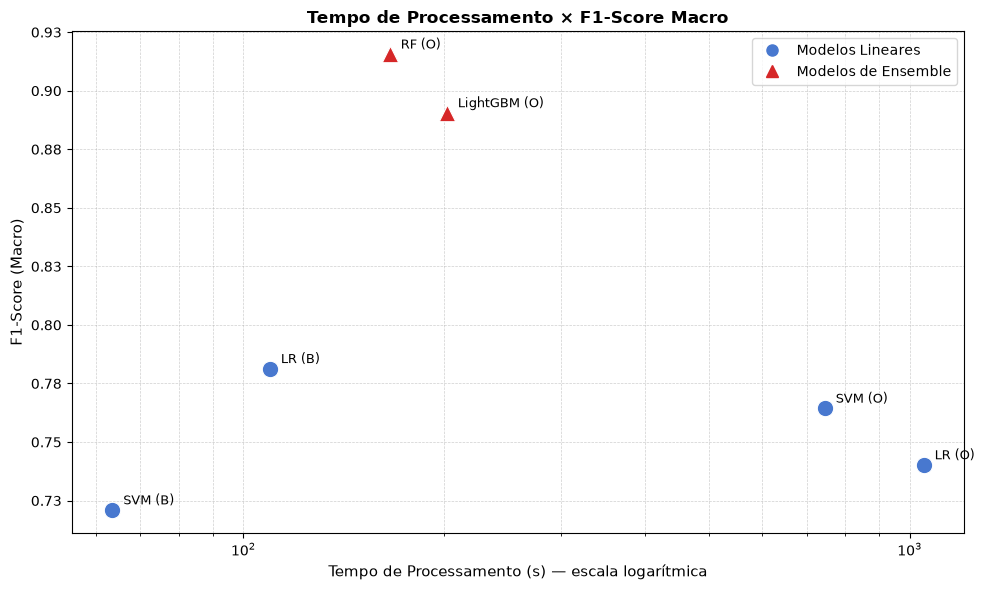

In [34]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np

# ── Dados dos 6 cenários ────────────────────────────────────────────────────
# Cada tupla: (label, tempo_s, f1_macro, cor, marcador, família)
cenarios = [
    ("LR (B)",      elapsed_logreg_base, f1_macro,           "#4878CF", "o", "linear"),
    ("SVM (B)",     elapsed_svm_base,    f1_macro_svm_base,  "#4878CF", "o", "linear"),
    ("LR (O)",      elapsed_logreg,      f1_logreg_tuned,    "#4878CF", "o", "linear"),
    ("SVM (O)",     elapsed_svm,         f1_svm_tuned,       "#4878CF", "o", "linear"),
    ("RF (O)",      elapsed_rf,          f1_rf_tuned,        "#D62728", "^", "ensemble"),
    ("LightGBM (O)",elapsed_lgbm,        f1_lgbm_tuned,      "#D62728", "^", "ensemble"),
]

labels   = [c[0] for c in cenarios]
tempos   = [c[1] for c in cenarios]
f1s      = [c[2] for c in cenarios]
cores    = [c[3] for c in cenarios]
markers  = [c[4] for c in cenarios]

# ── Figura ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

for label, tempo, f1, cor, marker in zip(labels, tempos, f1s, cores, markers):
    ax.scatter(
        tempo, f1,
        color=cor, marker=marker,
        s=140, zorder=5,
        edgecolors="white", linewidths=0.8
    )
    # anotação com pequeno deslocamento para não sobrepor o ponto
    ax.annotate(
        label,
        xy=(tempo, f1),
        xytext=(8, 4),
        textcoords="offset points",
        fontsize=9,
        color="black"
    )

# Escala log no eixo X — evita colapso visual entre modelos rápidos e lentos
ax.set_xscale("log")

ax.set_xlabel("Tempo de Processamento (s) — escala logarítmica", fontsize=11)
ax.set_ylabel("F1-Score (Macro)", fontsize=11)
ax.set_title(
    "Tempo de Processamento × F1-Score Macro",fontsize=12, fontweight="bold"
)

# ── Legenda de famílias ───────────────────────────────────────────────────
legend_linear = mlines.Line2D(
    [], [], color="#4878CF", marker="o", linestyle="None",
    markersize=8, label="Modelos Lineares"
)
legend_ensemble = mlines.Line2D(
    [], [], color="#D62728", marker="^", linestyle="None",
    markersize=8, label="Modelos de Ensemble"
)
ax.legend(handles=[legend_linear, legend_ensemble], fontsize=10)

ax.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.6)
ax.yaxis.set_major_formatter(plt.FormatStrFormatter("%.2f"))

plt.tight_layout()
plt.show()

#### Gráfico 2: Classificadores × Classes Difíceis (grayhole e random\_replay)

Barras agrupadas por classe (`grayhole` e `random_replay`), com um grupo de
6 barras para cada classe — uma barra por cenário.

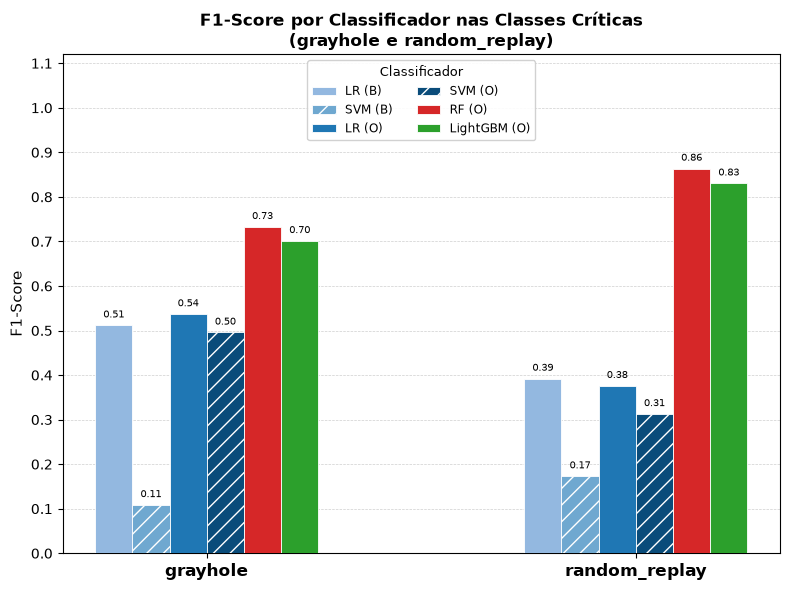

In [36]:
import matplotlib.pyplot as plt
import numpy as np

# ── Dados: f1-score individual por classe, para cada cenário ────────────────
# Os arrays f1_per_class_* têm índice igual ao label encoding de le.classes_
idx_grayhole     = class_to_idx["grayhole"]
idx_random_relay = class_to_idx["random_replay"]

modelos = [
    "LR (B)",
    "SVM (B)",
    "LR (O)",
    "SVM (O)",
    "RF (O)",
    "LightGBM (O)",
]

# Valores de F1 por modelo para cada classe crítica
f1_grayhole = [
    f1_per_class_logreg_base[idx_grayhole],
    f1_per_class_svm_base[idx_grayhole],
    f1_per_class_logreg[idx_grayhole],
    f1_per_class_svm[idx_grayhole],
    f1_per_class_rf[idx_grayhole],
    f1_per_class_lgbm[idx_grayhole],
]

f1_random_replay = [
    f1_per_class_logreg_base[idx_random_relay],
    f1_per_class_svm_base[idx_random_relay],
    f1_per_class_logreg[idx_random_relay],
    f1_per_class_svm[idx_random_relay],
    f1_per_class_rf[idx_random_relay],
    f1_per_class_lgbm[idx_random_relay],
]

# ── Layout das barras agrupadas ──────────────────────────────────────────────
n_modelos  = len(modelos)
n_classes  = 2                          # grayhole e random_replay
bar_width  = 0.13                       # largura de cada barra individual
group_gap  = 0.25                       # espaço entre os grupos de classes
x_classes  = np.array([0, group_gap * n_modelos])  # posição base de cada grupo

# Paleta de cores: lineares em azuis, ensembles em vermelho/verde
cores_barras = [
    "#93B8E0",  # LogReg Padrão         (azul claro)
    "#6FA8D0",  # SVM Padrão            (azul médio)
    "#1F77B4",  # LogReg Otimizado      (azul escuro)
    "#0A4C7A",  # SVM Otimizado         (azul muito escuro)
    "#D62728",  # Random Forest         (vermelho)
    "#2CA02C",  # LightGBM              (verde)
]

hatches = ["", "//", "", "//", "", ""]  # hachura para distinguir dentro da família

fig, ax = plt.subplots(figsize=(8, 6))

# Deslocamentos de cada barra dentro do grupo
offsets = np.linspace(
    -(n_modelos - 1) / 2 * bar_width,
     (n_modelos - 1) / 2 * bar_width,
    n_modelos
)

for i, (modelo, cor, hatch) in enumerate(zip(modelos, cores_barras, hatches)):
    valores = [f1_grayhole[i], f1_random_replay[i]]
    xpos    = x_classes + offsets[i]

    bars = ax.bar(
        xpos, valores,
        width=bar_width,
        color=cor,
        hatch=hatch,
        edgecolor="white",
        linewidth=0.6,
        label=modelo,
        zorder=3
    )

    # Valor numérico acima de cada barra
    for bar, val in zip(bars, valores):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            val + 0.012,
            f"{val:.2f}",
            ha="center", va="bottom",
            fontsize=7.5, color="black"
        )

# ── Eixos e formatação ────────────────────────────────────────────────────────
ax.set_xticks(x_classes)
ax.set_xticklabels(["grayhole", "random_replay"], fontsize=12, fontweight="bold")
ax.set_ylabel("F1-Score", fontsize=11)
ax.set_ylim(0, 1.12)
ax.yaxis.set_major_locator(plt.MultipleLocator(0.1))
ax.set_title(
    "F1-Score por Classificador nas Classes Críticas\n"
    "(grayhole e random_replay)",
    fontsize=12, fontweight="bold"
)

ax.legend(
    title="Classificador",
    title_fontsize=9,
    fontsize=8.5,
    loc="upper center",
    ncol=2,
    framealpha=0.9
)
ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.6, zorder=0)

plt.tight_layout()
plt.show()

#### Gráfico 3: Matriz de confusão - LightGBM

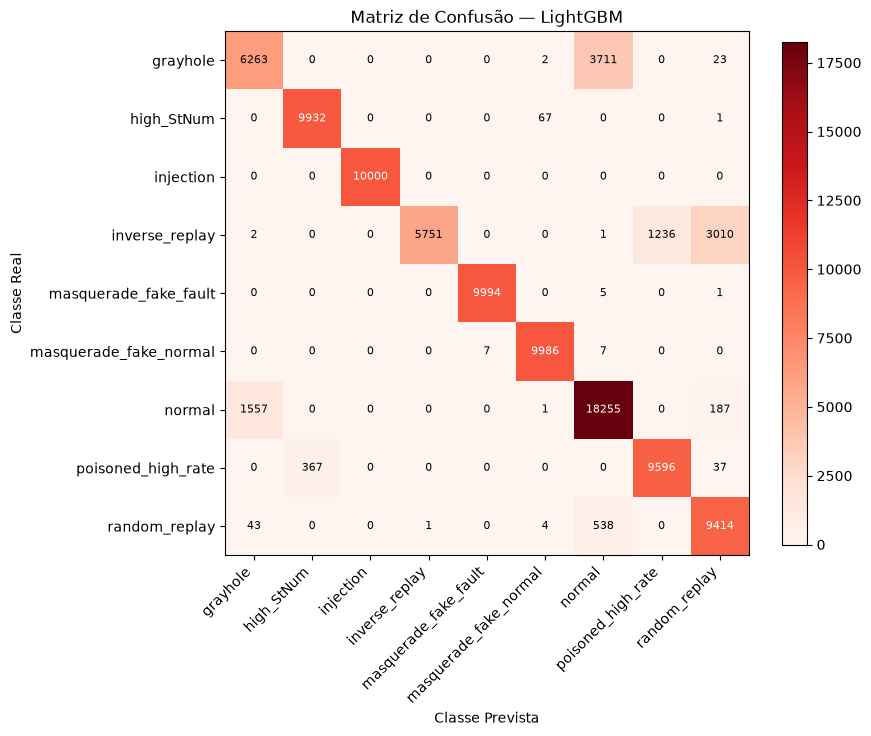

In [38]:
# Matriz de confusão melhor classificador (LightGBM)
from sklearn.metrics import confusion_matrix
cm_lgbm = confusion_matrix(y_test, y_pred_lgbm_tuned)

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(cm_lgbm, cmap="Reds")
ax.set_xticks(range(len(le.classes_)))
ax.set_yticks(range(len(le.classes_)))
ax.set_xticklabels(le.classes_, rotation=45, ha="right")
ax.set_yticklabels(le.classes_)
ax.set_xlabel("Classe Prevista")
ax.set_ylabel("Classe Real")
ax.set_title("Matriz de Confusão — LightGBM")

for i in range(cm_lgbm.shape[0]):
    for j in range(cm_lgbm.shape[1]):
        ax.text(j, i, cm_lgbm[i, j], ha="center", va="center",
                color="white" if cm_lgbm[i, j] > cm_lgbm.max() / 2 else "black", fontsize=8)

plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()